# Notebook 5: Đánh giá Tổng hợp

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from utils import load_registry

registry = load_registry()
metrics_list = registry['metrics_list']
cv_scores_dict = registry['cv_scores_dict']

## 6. Đánh giá Tổng hợp
### Bảng Phân Tích & Biểu Đồ


BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH
                                          Model CV_MSE (Mean ± Std) CV_RMSE (Mean ± Std) CV_MAE (Mean ± Std) CV_R2 (Mean ± Std)       Val MSE   Val RMSE    Val MAE    Val R2      Test MSE  Test RMSE   Test MAE   Test R2
                              Kernel Ridge (CV)   2070.02 ± 3533.15        37.07 ± 26.37       24.37 ± 17.56    0.9339 ± 0.0677  11171.963304 105.697509  69.563471  0.766843  19765.911919 140.591294  99.098055  0.593407
              Ridge + B-Spline (knots=4, deg=3)  13590.76 ± 7127.21       112.95 ± 28.88       86.76 ± 22.88    0.3213 ± 0.3629  26857.241620 163.881792 129.500734  0.439493  26346.591975 162.316333 120.955869  0.458040
                   Ridge + Gaussian RBF (n=100)  11297.39 ± 4538.71       104.09 ± 21.49       79.03 ± 13.92    0.3957 ± 0.3280  16030.531141 126.611734  93.337172  0.665445  28928.968472 170.085180 117.544579  0.404920
                     Ridge + Polynomial (deg=2)  14111.80 ± 7584.45       114.

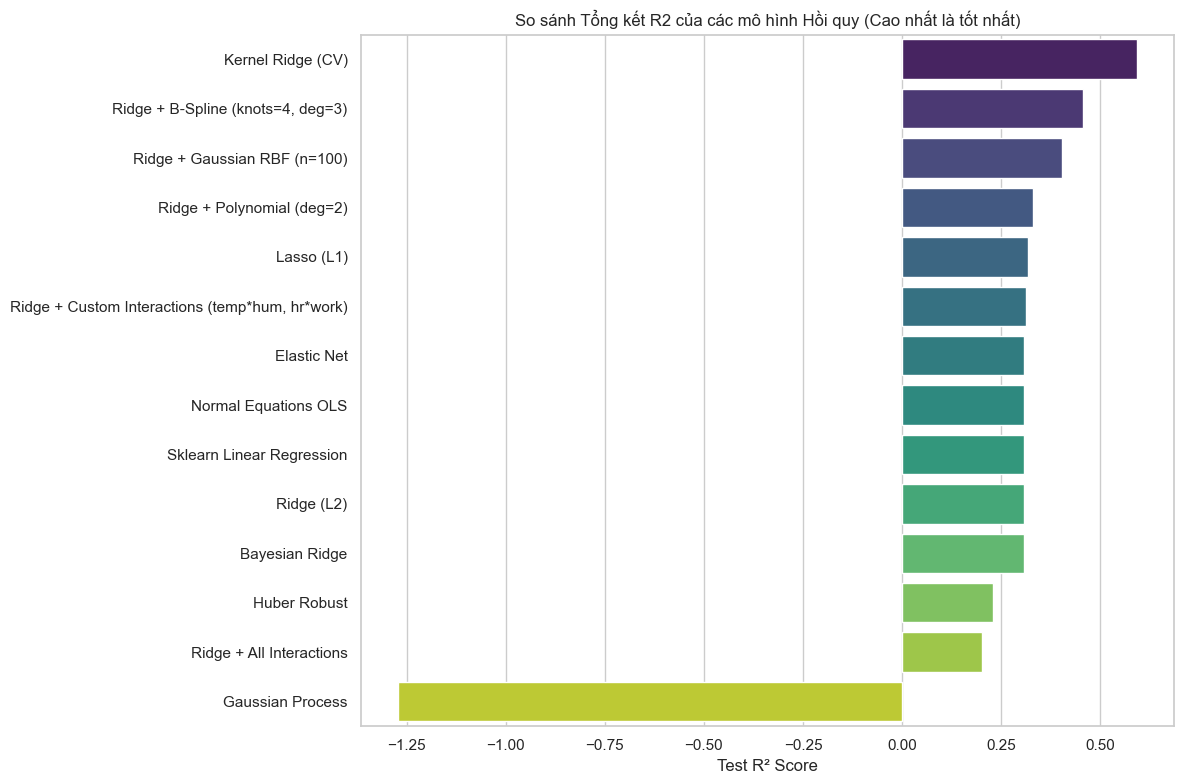

In [2]:
import pandas as pd
import seaborn as sns
from scipy.stats import wilcoxon

print("\n" + "=" * 60)
print("BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH")
print("=" * 60)

# Tạo DataFrame từ metrics_list
results_df = pd.DataFrame(metrics_list)

# Sắp xếp theo Test R2 giảm dần
results_df_sorted = results_df.sort_values(by="Test R2", ascending=False)
print(results_df_sorted.to_string(index=False))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=results_df_sorted,
    x="Test R2",
    y="Model",
    palette="viridis",
)
plt.title("So sánh Tổng kết R2 của các mô hình Hồi quy (Cao nhất là tốt nhất)")
plt.xlabel("Test R² Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Kiểm định Thống kê (Wilcoxon Signed-Rank Test)
So sánh mô hình có lượng lỗi RMSE bé nhất trên tập Cross-Validation (K-Fold)
với tất cả các mô hình còn lại nhằm xác nhận ý nghĩa thống kê của sự cải thiện.

In [3]:
print("\n" + "=" * 60)
print("KIỂM ĐỊNH THỐNG KÊ WILCOXON SIGNED-RANK TEST (10-FOLD CV RMSE)")
print("=" * 60)

# Tìm mô hình tốt nhất (RMSE trung bình trên tập CV nhỏ nhất)
best_model_name = min(cv_scores_dict, key=lambda k: np.mean(cv_scores_dict[k]))
best_model_cv_scores = cv_scores_dict[best_model_name]

print(f"Mô hình tốt nhất (Tham chiếu): '{best_model_name}'")
print("-" * 60)

for m in metrics_list:
    current_model = m["Model"]
    if current_model == best_model_name:
        continue

    current_model_cv_scores = cv_scores_dict[current_model]

    # Thực hiện kiểm định Wilcoxon
    try:
        stat, p_value = wilcoxon(best_model_cv_scores, current_model_cv_scores)

        print(f"So sánh với '{current_model}':")
        print(f"   => p-value = {p_value:.4e}")
        if p_value < 0.05:
            print(
                f"   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). '{best_model_name}' thực sự ưu việt hơn."
            )
        else:
            print(
                f"   => KẾT LUẬN: KHÔNG có khác biệt có ý nghĩa thống kê. Hai mô hình hoạt động tương đương nhau."
            )
    except Exception as e:
        print(f"So sánh với '{current_model}': Bỏ qua kiểm định do ({str(e)})")
    print("-" * 60)


KIỂM ĐỊNH THỐNG KÊ WILCOXON SIGNED-RANK TEST (10-FOLD CV RMSE)
Mô hình tốt nhất (Tham chiếu): 'Kernel Ridge (CV)'
------------------------------------------------------------
So sánh với 'Normal Equations OLS':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'Sklearn Linear Regression':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'Ridge (L2)':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'Lasso (L1)':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt h